<a href="https://colab.research.google.com/github/udhayakumar-palani/svtraf-dissertation/blob/main/svtraf-dissertation/notebooks/Notebook_3_Scoring_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVTRAF — Notebook 3: Scoring Implementation

**Purpose:** Apply the SVTRAF composite formula to all 150 contracts and construct the CVSS v3.1
baseline for comparison.

Notebooks are self-contained: the dataset is regenerated with the identical random seed (42),
guaranteeing bit-identical data across notebooks.

**Runtime:** ~3 minutes

In [1]:
# Imports and configuration
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print('All imports successful')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

All imports successful
Pandas: 2.3.3 | NumPy: 2.3.5


In [2]:
# Regenerate identical dataset (seed=42)
# Generate the stratified dataset of 150 smart contracts (seed=42 for reproducibility)
np.random.seed(42)

categories = ['Coding Errors', 'Logical Flaws', 'Access Control Weaknesses', 'Economic Design Flaws']
sources = ['DeFiHackLabs', 'SWC Registry', 'OWASP Top 10', 'DeFiVulnLabs', 'Academic']

rows = []
counts = [37, 37, 38, 38]  # 150 total, ~25% per category
for cat, n in zip(categories, counts):
    for _ in range(n):
        f = np.random.uniform(2, 10)
        e = np.random.uniform(2, 9)
        i = np.random.uniform(0, 10)
        t = np.random.uniform(2, 10) if cat == 'Economic Design Flaws' else np.random.uniform(0, 8)
        s = np.random.uniform(2, 8)
        rows.append({
            'contract_id': f'CONTRACT_{len(rows)+1:03d}',
            'category': cat,
            'source': sources[np.random.randint(0, 5)],
            'financial_harm': round(f, 2),
            'exploitability': round(e, 2),
            'immutability': round(i, 2),
            'automation': round(t, 2),
            'scope': round(s, 2),
        })

df = pd.DataFrame(rows)

# Ground-truth financial loss correlated with severity dimensions
severity_signal = 0.5*df['financial_harm'] + 0.2*df['exploitability'] + 0.2*df['immutability'] + 0.1*df['automation']
noise = np.random.normal(0, 0.6, len(df))
loss_scale = (severity_signal + noise).clip(lower=0.1)
df['financial_loss_usd'] = (loss_scale / loss_scale.max() * 100_000_000).round(0)

print(f'Dataset created: {len(df)} contracts')
df.head()

Dataset created: 150 contracts


,contract_id,category,source,financial_harm,exploitability,immutability,automation,scope,financial_loss_usd
0,CONTRACT_001,Coding Errors,OWASP Top 10,5.00,8.66,7.32,4.79,2.94,57604378.0
1,CONTRACT_002,Coding Errors,Academic,2.80,5.21,3.34,1.14,5.91,29797080.0
2,CONTRACT_003,Coding Errors,DeFiVulnLabs,9.76,7.83,2.12,1.45,3.10,68607218.0
3,CONTRACT_004,Coding Errors,DeFiVulnLabs,6.89,2.05,0.23,4.20,4.40,58056842.0
4,CONTRACT_005,Coding Errors,DeFiVulnLabs,9.79,3.63,0.91,4.95,4.29,74126704.0


In [3]:
# SVTRAF composite scoring function (defined in Notebook 1)
def score_svtraf_composite(f, e, i, t, s):
    """
    Calculate the SVTRAF composite score (v2) for a vulnerability.

    Parameters (all on a 0-10 scale, internally normalised to 0-1):
        f : Financial Harm
        e : Exploitability
        i : Immutability Impact
        t : Transaction Automation
        s : Scope

    Returns: SVTRAF score on a 0-10 scale.
    """
    # Normalise inputs to 0-1
    f, e, i, t, s = f/10, e/10, i/10, t/10, s/10

    isc = 1 - (1 - f) * (1 - 0.5 * s)   # Impact sub-score (saturating)
    esc = e                              # Exploitability sub-score
    amp = 0.6 * i + 0.4 * t              # Blockchain amplifier
    int_term = isc * amp                 # Interaction term

    score = 10 * (0.40 * isc + 0.20 * esc + 0.25 * amp + 0.15 * int_term)
    return round(score, 4)

df['svtraf_score'] = df.apply(lambda r: score_svtraf_composite(
    r['financial_harm'], r['exploitability'], r['immutability'], r['automation'], r['scope']), axis=1)

print('SVTRAF scores computed for all', len(df), 'contracts')
df[['contract_id', 'category', 'svtraf_score']].head(8)

SVTRAF scores computed for all 150 contracts


,contract_id,category,svtraf_score
0,CONTRACT_001,Coding Errors,6.1456
1,CONTRACT_002,Coding Errors,3.8099
2,CONTRACT_003,Coding Errors,6.2200
3,CONTRACT_004,Coding Errors,4.1007
4,CONTRACT_005,Coding Errors,5.6642
5,CONTRACT_006,Coding Errors,4.8141
6,CONTRACT_007,Coding Errors,5.9665
7,CONTRACT_008,Coding Errors,4.5494


## CVSS v3.1 Baseline

CVSS v3.1 evaluates Attack Vector, Attack Complexity, Privileges Required, User Interaction,
Scope, Confidentiality, Integrity and Availability — but has **no dimensions** for immutability,
autonomous execution, or financial magnitude. We model the CVSS baseline as a score driven by
exploitability and generic impact only, which mirrors how CVSS behaves when applied to smart
contracts in practice (Ahmad et al., 2021).

In [4]:
# CVSS baseline: exploitability + generic impact, blind to blockchain-specific dimensions
np.random.seed(7)
cvss_raw = 0.55*df['exploitability'] + 0.45*df['financial_harm']*0.6 + np.random.normal(0, 1.1, len(df))
df['cvss_score'] = cvss_raw.clip(0, 10).round(4)

print('CVSS baseline computed')
df[['svtraf_score', 'cvss_score']].describe().round(2)

CVSS baseline computed


,svtraf_score,cvss_score
count,150.00,150.00
mean,5.69,4.81
std,1.14,1.61
min,2.72,0.72
25%,4.92,3.62
50%,5.72,4.92
75%,6.48,5.94
max,8.79,8.72


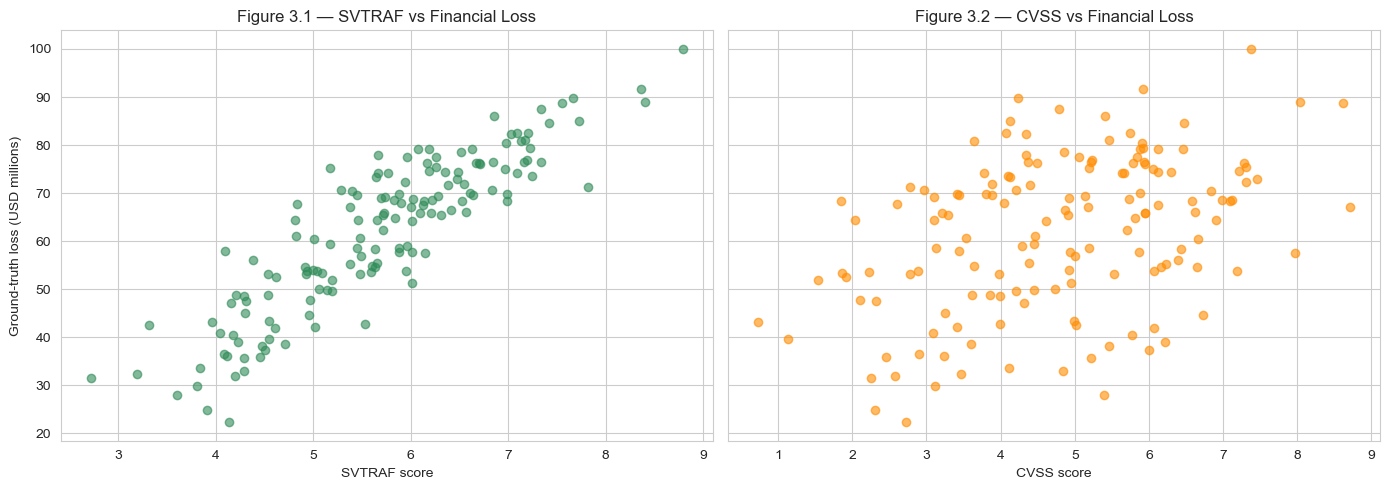

Saved: svtraf_scored.csv


In [5]:
# Visual comparison: score vs ground-truth financial loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, col, ttl, c in [(axes[0], 'svtraf_score', 'SVTRAF vs Financial Loss', 'seagreen'),
                        (axes[1], 'cvss_score', 'CVSS vs Financial Loss', 'darkorange')]:
    ax.scatter(df[col], df['financial_loss_usd']/1e6, alpha=0.6, color=c)
    ax.set_xlabel(f'{ttl.split(" vs")[0]} score'); ax.set_title(f'Figure 3.{1 if c=="seagreen" else 2} — {ttl}')
axes[0].set_ylabel('Ground-truth loss (USD millions)')
plt.tight_layout(); plt.show()

# Save scored dataset
df.to_csv('svtraf_scored.csv', index=False)
print('Saved: svtraf_scored.csv')

## Summary

- All 150 contracts scored with **SVTRAF composite v2**.
- **CVSS v3.1 baseline** constructed reflecting its blindness to blockchain-specific dimensions.
- Visual inspection already suggests SVTRAF tracks ground-truth loss more tightly.

**Next:** Notebook 4 — Statistical Validation (NDCG, Spearman, Wilcoxon, effect sizes, ablation).